<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="https://www.um.es/documents/1073494/42130150/LogosimboloUMU-positivo.png" alt="UMU" style="height:200px; width:auto;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="https://www.upct.es/contenido/universidad/galeria/identidad-2021/logos/logos-upct/marca-upct/marca-principal/horizontal/azul.png" alt="UPCT" style="height:145px; width:auto;">
</div>

# Segmentacion tumoral en CT pulmonar - Pipeline MONAI 3D

Cuaderno entregable del proyecto. Resume el flujo activo (SegResNet 3D
patch-based con MONAI), su justificacion frente a las iteraciones previas y los
resultados sobre el dataset `Task06_Lung` del Medical Segmentation Decathlon.

**Cuaderno auto-contenido:** todo el codigo del pipeline (configuracion,
transforms, modelo, entrenamiento, inferencia, evaluacion y ablacion) esta
definido directamente aqui. Solo se necesitan paquetes del entorno virtual
(torch, monai, scipy, sklearn, pandas, matplotlib, nibabel) y la carpeta
`data/Task06_Lung` (que se descarga automaticamente si no existe).

**Contenido:**
1. Configuracion del entorno y descarga del dataset.
2. Configuracion central del pipeline (constantes inline).
3. Utilidades de visualizacion y metricas.
4. Construccion de transforms, modelo, inferencia y entrenamiento.
5. Inspeccion del dataset.
6. Entrenamiento (o reutilizacion del checkpoint guardado).
7. Busqueda de threshold y TTA opcional.
8. Comparativa frente al 3D legado y al 2D historico.
9. Visualizacion de predicciones.
10. Ablacion fraccion de datos vs regimen de augmentacion.
11. Conclusiones.

**Importante:** el entrenamiento real requiere GPU. En CPU el cuaderno detecta
automaticamente y se ejecuta en modo `MONAI_FAST_DEV=1` (smoke test) salvo que
se fije la variable explicitamente.

## 1. Configuracion del entorno cloud

In [1]:
# Detecta el entorno (Colab, Kaggle, otro) y muestra GPU disponible.
import os, sys, subprocess, platform
from pathlib import Path


def _detectar_entorno() -> str:
    if "google.colab" in sys.modules or os.environ.get("COLAB_RELEASE_TAG"):
        return "colab"
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE"):
        return "kaggle"
    if os.environ.get("SM_FRAMEWORK_PARAMS"):
        return "sagemaker"
    return "local"


ENTORNO = _detectar_entorno()
print(f"Entorno detectado: {ENTORNO}")
print(f"Python: {platform.python_version()} | OS: {platform.system()} {platform.release()}")

Entorno detectado: local
Python: 3.11.14 | OS: Linux 6.17.0-22-generic


In [2]:
# Comprueba que torch+CUDA estan disponibles antes de continuar.
try:
    import torch

    print(f"torch={torch.__version__} | cuda={torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
        os.environ.setdefault("MONAI_FAST_DEV", "0")
    else:
        print("No hay GPU. Activando MONAI_FAST_DEV=1 para smoke test rapido.")
        os.environ["MONAI_FAST_DEV"] = "1"
except ImportError:
    print("torch no esta instalado. Ejecuta la celda de instalacion siguiente.")

torch=2.11.0+cu130 | cuda=True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM total: 8.1 GB


In [3]:
# Instalacion de dependencias. Idempotente: si ya estan, no hace nada.
# Descomenta si tu entorno cloud no tiene MONAI/torch preinstalados.
INSTALAR_DEPS = ENTORNO in {"colab", "kaggle"}
if INSTALAR_DEPS:
    paquetes = [
        "monai>=1.5",
        "nibabel>=5.0",
        "scikit-learn>=1.3",
        "matplotlib>=3.7",
        "pandas>=2.0",
        "scipy>=1.11",
    ]
    print("Instalando dependencias...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *paquetes])
    print("Dependencias instaladas.")
else:
    print("Saltando instalacion (entorno local). Ajusta INSTALAR_DEPS si es necesario.")

Saltando instalacion (entorno local). Ajusta INSTALAR_DEPS si es necesario.


In [4]:
# Localiza la raiz del proyecto. Solo necesitamos saber donde viven los
# directorios `data/`, `modelos/` y `resultados/`. El cuaderno NO importa nada
# del paquete local: todo el pipeline esta definido inline mas abajo.
NB_DIR = Path.cwd()
candidatos = [NB_DIR, NB_DIR.parent, *NB_DIR.parents]
RAIZ = next(
    (p for p in candidatos if (p / "data").exists() or (p / "pyproject.toml").exists()),
    NB_DIR,
)
os.chdir(RAIZ)
print(f"Raiz del proyecto: {RAIZ}")

Raiz del proyecto: /home/pyros05/Escritorio/Proyecto_MONAI


## 2. Descarga del dataset Task06_Lung

In [5]:
# Si el dataset no esta presente, lo descarga via monai.apps.DecathlonDataset.
# Tarda unos minutos (descomprime ~25 GB).
DATASET_DIR = RAIZ / "data" / "Task06_Lung"
DATASET_JSON = DATASET_DIR / "dataset.json"

if DATASET_JSON.exists():
    print(f"Dataset ya disponible en {DATASET_DIR}")
else:
    from monai.apps import DecathlonDataset

    DATASET_DIR.parent.mkdir(parents=True, exist_ok=True)
    print("Descargando Task06_Lung (puede tardar 10-20 min)...")
    _ = DecathlonDataset(
        root_dir=str(RAIZ / "data"),
        task="Task06_Lung",
        section="training",
        download=True,
        cache_rate=0.0,
        num_workers=0,
        transform=None,
    )
    print(f"Dataset listo en {DATASET_DIR}")

Dataset ya disponible en /home/pyros05/Escritorio/Proyecto_MONAI/data/Task06_Lung


## 3. Configuracion del pipeline activo

Constantes que controlan el pipeline 3D. Son las mismas que vivian en
`scripts/monai_pipeline/core/config.py` (preservadas verbatim para mantener la
trazabilidad con el codigo del proyecto), pero ahora estan inline para que el
cuaderno funcione sin dependencias del repositorio.

In [6]:
# Configuracion central inline (extraida del paquete del proyecto).
# Mismas claves y defaults que el codigo del repo. Cualquier override via
# variable de entorno (MONAI_*) sigue funcionando.
from monai.utils.misc import set_determinism


def _env_bool(nombre: str, por_defecto: bool = False) -> bool:
    valor = os.getenv(nombre)
    if valor is None:
        return por_defecto
    return valor.strip().lower() in {"1", "true", "yes", "on"}


def _env_int(nombre: str, por_defecto: int) -> int:
    valor = os.getenv(nombre)
    return por_defecto if valor is None else int(valor)


def _env_float(nombre: str, por_defecto: float) -> float:
    valor = os.getenv(nombre)
    return por_defecto if valor is None else float(valor)


# --- Rutas ----------------------------------------------------------------
DIR_DATOS = RAIZ / "data"
DIR_MODELOS = RAIZ / "modelos"
DIR_RESULTADOS = RAIZ / "resultados"
DIR_FIGURAS = DIR_RESULTADOS / "figuras"
DIR_METRICAS = DIR_RESULTADOS / "metricas"
for d in [DIR_DATOS, DIR_MODELOS, DIR_RESULTADOS, DIR_FIGURAS, DIR_METRICAS]:
    d.mkdir(parents=True, exist_ok=True)

TASK = "Task06_Lung"
TASK_DIR = DIR_DATOS / TASK
RUTA_DATASET_JSON = TASK_DIR / "dataset.json"

# --- Reproducibilidad -----------------------------------------------------
SEMILLA = 42
set_determinism(seed=SEMILLA)

# --- CPU / GPU ------------------------------------------------------------
N_CPU = os.cpu_count() or 1
N_WORKERS_PREPROCESADO = max(1, min(4, N_CPU - 1))
N_WORKERS_DATALOADER = 0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"

if DEVICE.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
else:
    torch.set_num_threads(max(1, N_CPU - 1))

# --- Dataset / preprocesado ----------------------------------------------
TARGET_SPACING_3D = (1.0, 1.0, 2.0)
CT_CLIP_RANGE = (-1024.0, 400.0)
N_FOLDS_KFOLD = 5
KFOLD_DEFAULT_INDEX = 0
# 256 voxels @ spacing (1,1,2) ~ 512 mm^3 ~ 1 cm de diametro.
MIN_COMPONENT_SIZE = 256

# --- Entrenamiento --------------------------------------------------------
FAST_DEV_RUN = _env_bool("MONAI_FAST_DEV", False)
LR_WARMUP_EPOCAS = _env_int("MONAI_LR_WARMUP_EPOCAS", 3 if not FAST_DEV_RUN else 1)

# --- Pipeline 3D activo (patch-based con SegResNet) ----------------------
MODELO_3D_NOMBRE = "SegResNet3D-Patch"
RUTA_MODELO_3D = DIR_MODELOS / "mejor_SegResNet3D_patch.pth"

# 96^3 a spacing (1,1,2) cubre ~9.6 x 9.6 x 19.2 cm.
PATCH_SIZE_3D = (96, 96, 96)

SAMPLES_PER_VOLUME_3D = _env_int("MONAI_SAMPLES_PER_VOLUME", 4 if not FAST_DEV_RUN else 2)
POS_NEG_RATIO_3D = _env_float("MONAI_POS_NEG_RATIO", 1.0)

TRAIN_BATCH_SIZE_3D = _env_int(
    "MONAI_BATCH_SIZE_3D",
    (2 if AMP_ENABLED else 1) if not FAST_DEV_RUN else 1,
)
INFER_SW_BATCH_3D = _env_int(
    "MONAI_INFER_SW_BATCH",
    (4 if AMP_ENABLED else 1) if not FAST_DEV_RUN else 1,
)
INFER_OVERLAP_3D = _env_float("MONAI_INFER_OVERLAP", 0.5)

SEGRESNET_INIT_FILTERS = _env_int("MONAI_SEGRESNET_INIT_FILTERS", 16)
SEGRESNET_DROPOUT = _env_float("MONAI_SEGRESNET_DROPOUT", 0.2)

LR_3D = _env_float("MONAI_LR_3D", 1e-4)
WEIGHT_DECAY_3D = _env_float("MONAI_WEIGHT_DECAY_3D", 1e-5)
NUM_EPOCAS_3D = _env_int("MONAI_NUM_EPOCHS_3D", 200 if not FAST_DEV_RUN else 2)
EARLY_STOPPING_PATIENCE_3D = _env_int(
    "MONAI_EARLY_STOPPING_PATIENCE_3D", 25 if not FAST_DEV_RUN else 2
)
NUM_EPOCAS_ABLACION_3D = _env_int(
    "MONAI_NUM_EPOCHS_ABLACION_3D", 80 if not FAST_DEV_RUN else 1
)
VAL_INTERVAL_3D = _env_int("MONAI_VAL_INTERVAL_3D", 2 if not FAST_DEV_RUN else 1)
CACHE_RATE_3D = _env_float("MONAI_CACHE_RATE", 1.0 if not FAST_DEV_RUN else 0.0)

SEGMENTATION_AUGMENT_LEVEL = _env_int("MONAI_SEGMENTATION_AUGMENT_LEVEL", 1)
SEGMENTATION_THRESHOLD_MIN = _env_float("MONAI_SEGMENTATION_THRESHOLD_MIN", 0.20)
SEGMENTATION_THRESHOLD_MAX = _env_float("MONAI_SEGMENTATION_THRESHOLD_MAX", 0.80)
SEGMENTATION_THRESHOLD_STEP = _env_float("MONAI_SEGMENTATION_THRESHOLD_STEP", 0.05)
SEGMENTATION_ENABLE_TTA_FINAL = _env_bool(
    "MONAI_SEGMENTATION_ENABLE_TTA_FINAL", not FAST_DEV_RUN
)

LOSS_LAMBDA_DICE = _env_float("MONAI_LOSS_LAMBDA_DICE", 0.5)
LOSS_LAMBDA_FOCAL = _env_float("MONAI_LOSS_LAMBDA_FOCAL", 0.5)
LOSS_FOCAL_GAMMA = _env_float("MONAI_LOSS_FOCAL_GAMMA", 2.0)

# --- Ablacion -------------------------------------------------------------
FRACCIONES_DATOS = [0.25, 0.50, 1.00]
NOMBRES_REGIMEN = {1: "Base", 2: "Fuerte"}

# --- Colores --------------------------------------------------------------
COLORES = {
    "3D legado": "#8d6e63",
    MODELO_3D_NOMBRE: "#7c3aed",
    "Base": "#43a047",
    "Fuerte": "#fb8c00",
}

# --- Resultados 3D legados (para comparativa historica) ------------------
LEGACY_3D_METRICS = [
    {
        "metodo": "DynUNet",
        "tipo": "3D legado",
        "dice_medio": 0.33071640133857727,
        "dice_std": 0.0,
        "hd95_medio_mm": 0.0,
        "sensibilidad": 0.0,
        "especificidad": 0.0,
        "n_eval": 10,
        "parametros": 16539432,
        "tiempo_total_s": 4561.7,
    },
    {
        "metodo": "SegResNet",
        "tipo": "3D legado",
        "dice_medio": 0.31637245416641235,
        "dice_std": 0.0,
        "hd95_medio_mm": 0.0,
        "sensibilidad": 0.0,
        "especificidad": 0.0,
        "n_eval": 10,
        "parametros": 4700914,
        "tiempo_total_s": 6255.7,
    },
    {
        "metodo": "UNet",
        "tipo": "3D legado",
        "dice_medio": 0.21313409507274628,
        "dice_std": 0.0,
        "hd95_medio_mm": 0.0,
        "sensibilidad": 0.0,
        "especificidad": 0.0,
        "n_eval": 10,
        "parametros": 4806481,
        "tiempo_total_s": 1234.8,
    },
]

print("Pipeline activo:", MODELO_3D_NOMBRE)
print("Device:", DEVICE, "| AMP:", AMP_ENABLED, "| FAST_DEV:", FAST_DEV_RUN)
print(
    "Patch size:", PATCH_SIZE_3D,
    "| samples/volumen:", SAMPLES_PER_VOLUME_3D,
    "| pos/neg:", POS_NEG_RATIO_3D,
)
print(
    "Batch train:", TRAIN_BATCH_SIZE_3D,
    "| sw_batch:", INFER_SW_BATCH_3D,
    "| overlap:", INFER_OVERLAP_3D,
)
print("SegResNet init_filters:", SEGRESNET_INIT_FILTERS, "| dropout:", SEGRESNET_DROPOUT)
print("Epochs:", NUM_EPOCAS_3D, "| patience:", EARLY_STOPPING_PATIENCE_3D)
print("LR:", LR_3D, "| weight_decay:", WEIGHT_DECAY_3D, "| warmup:", LR_WARMUP_EPOCAS)
print(
    "Loss: DiceFocalLoss(lambda_dice=", LOSS_LAMBDA_DICE,
    ", lambda_focal=", LOSS_LAMBDA_FOCAL,
    ", gamma=", LOSS_FOCAL_GAMMA, ")",
    sep="",
)
print(
    "Augment level:", SEGMENTATION_AUGMENT_LEVEL,
    f"({NOMBRES_REGIMEN.get(SEGMENTATION_AUGMENT_LEVEL)}) | TTA final:",
    SEGMENTATION_ENABLE_TTA_FINAL,
)

Pipeline activo: SegResNet3D-Patch
Device: cuda | AMP: True | FAST_DEV: False
Patch size: (96, 96, 96) | samples/volumen: 4 | pos/neg: 1.0
Batch train: 2 | sw_batch: 4 | overlap: 0.5
SegResNet init_filters: 16 | dropout: 0.2
Epochs: 200 | patience: 25
LR: 0.0001 | weight_decay: 1e-05 | warmup: 3
Loss: DiceFocalLoss(lambda_dice=0.5, lambda_focal=0.5, gamma=2.0)
Augment level: 1 (Base) | TTA final: True


## 4. Utilidades inline

Funciones de visualizacion (estilo oscuro, ventaneo CT, montaje de slices) y
metricas (Dice, HD95, sensibilidad, especificidad, precision). Equivalentes a
las del modulo `monai_pipeline.core.utils` original.

In [7]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from monai.metrics import compute_hausdorff_distance
from scipy import ndimage


ESTILO_OSCURO = {
    "figure.facecolor": "#0f172a",
    "axes.facecolor": "#111827",
    "axes.edgecolor": "#cbd5e1",
    "axes.labelcolor": "#e2e8f0",
    "text.color": "#e2e8f0",
    "xtick.color": "#cbd5e1",
    "ytick.color": "#cbd5e1",
    "grid.color": "#334155",
    "grid.alpha": 0.25,
    "font.size": 11,
    "axes.titlesize": 13,
    "figure.titlesize": 15,
    "legend.facecolor": "#111827",
    "legend.edgecolor": "#334155",
    "text.usetex": False,
}


def estilo_oscuro() -> None:
    plt.rcParams.update(ESTILO_OSCURO)


def ventanear(imagen: np.ndarray, width: float, level: float) -> np.ndarray:
    hu_min = level - width / 2.0
    hu_max = level + width / 2.0
    return np.clip((imagen - hu_min) / max(hu_max - hu_min, 1e-8), 0.0, 1.0)


def guardar_json(datos, ruta: Path) -> None:
    with open(ruta, "w", encoding="utf-8") as handle:
        json.dump(datos, handle, indent=2, ensure_ascii=False, default=str)
    print(f"  -> {ruta.name}")


def guardar_csv(df: pd.DataFrame, ruta: Path) -> None:
    df.to_csv(ruta, index=False, encoding="utf-8")
    print(f"  -> {ruta.name}")


def guardar_figura(fig: Figure, ruta: Path, dpi: int = 150) -> None:
    fig.savefig(
        ruta,
        dpi=dpi,
        bbox_inches="tight",
        facecolor=fig.get_facecolor(),
        edgecolor="none",
    )
    plt.close(fig)
    print(f"  -> {ruta.name}")


def limpiar_componentes_pequenas(
    mascara: np.ndarray,
    min_size: int,
    max_componentes: int = 2,
) -> np.ndarray:
    etiquetada, n = ndimage.label(mascara > 0)
    if n == 0:
        return np.zeros_like(mascara, dtype=np.uint8)
    tamanos = ndimage.sum(mascara > 0, etiquetada, range(1, n + 1))
    orden = np.argsort(tamanos)[::-1]
    salida = np.zeros_like(mascara, dtype=np.uint8)
    kept = 0
    for idx in orden:
        etiqueta = idx + 1
        tam = int(tamanos[idx])
        if tam < min_size:
            continue
        salida[etiquetada == etiqueta] = 1
        kept += 1
        if kept >= max_componentes:
            break
    return salida


def seleccionar_indices_tumor(mascara: np.ndarray, n: int = 6) -> list[int]:
    positivos = np.flatnonzero(np.sum(mascara > 0, axis=(1, 2)) > 0)
    if len(positivos) == 0:
        return [mascara.shape[0] // 2]
    if len(positivos) <= n:
        return positivos.tolist()
    idx = np.linspace(0, len(positivos) - 1, n, dtype=int)
    return positivos[idx].tolist()


def dice_score(pred: np.ndarray, gt: np.ndarray) -> float:
    pred_b = pred > 0
    gt_b = gt > 0
    inter = np.sum(pred_b & gt_b)
    total = np.sum(pred_b) + np.sum(gt_b)
    if total == 0:
        return 1.0
    return float(2.0 * inter / total)


def sensibilidad(pred: np.ndarray, gt: np.ndarray) -> float:
    gt_b = gt > 0
    tp = np.sum((pred > 0) & gt_b)
    fn = np.sum((pred == 0) & gt_b)
    return float(tp / max(tp + fn, 1))


def especificidad(pred: np.ndarray, gt: np.ndarray) -> float:
    gt_b = gt > 0
    tn = np.sum((pred == 0) & (~gt_b))
    fp = np.sum((pred > 0) & (~gt_b))
    return float(tn / max(tn + fp, 1))


def precision_score(pred: np.ndarray, gt: np.ndarray) -> float:
    tp = np.sum((pred > 0) & (gt > 0))
    fp = np.sum((pred > 0) & (gt == 0))
    return float(tp / max(tp + fp, 1))


def hausdorff_95(
    pred: np.ndarray,
    gt: np.ndarray,
    spacing: tuple[float, ...],
) -> float:
    pred_b = pred > 0
    gt_b = gt > 0
    if not np.any(pred_b) or not np.any(gt_b):
        return float("inf")
    try:
        struct = ndimage.generate_binary_structure(3, 1)
        pred_surf = pred_b ^ ndimage.binary_erosion(pred_b, struct)
        gt_surf = gt_b ^ ndimage.binary_erosion(gt_b, struct)
        dt_gt = ndimage.distance_transform_edt(~gt_b, sampling=spacing)
        dt_pred = ndimage.distance_transform_edt(~pred_b, sampling=spacing)
        d1 = np.percentile(dt_gt[pred_surf], 95) if np.any(pred_surf) else float("inf")
        d2 = np.percentile(dt_pred[gt_surf], 95) if np.any(gt_surf) else float("inf")
        return round(float(max(d1, d2)), 2)
    except Exception:
        pred_t = torch.from_numpy(pred_b).unsqueeze(0).unsqueeze(0).float()
        gt_t = torch.from_numpy(gt_b).unsqueeze(0).unsqueeze(0).float()
        try:
            hd95_monai = compute_hausdorff_distance(pred_t, gt_t, percentile=95, spacing=spacing)
            return round(float(hd95_monai.item()), 2)
        except RuntimeError:
            return float("inf")


def evaluar_segmentacion(
    pred: np.ndarray,
    gt: np.ndarray,
    spacing: tuple[float, ...],
) -> dict[str, float]:
    return {
        "dice": round(dice_score(pred, gt), 4),
        "hd95_mm": hausdorff_95(pred, gt, spacing),
        "sensibilidad": round(sensibilidad(pred, gt), 4),
        "especificidad": round(especificidad(pred, gt), 4),
        "precision": round(precision_score(pred, gt), 4),
        "voxeles_pred": int(np.sum(pred > 0)),
        "voxeles_gt": int(np.sum(gt > 0)),
    }

## 5. Recorrido del proyecto

| Iteracion | Estrategia | Mejor Dice (val) | Status |
|---|---|---|---|
| Original | DynUNet 3D legado | 0.331 | archivada |
| Original | SegResNet 3D legado | 0.316 | archivada |
| Original | UNet 3D legado | 0.213 | archivada |
| 2D v1-v3 | UNet 2D axial sin priors | sin checkpoint definitivo | abandonada |
| 2D v4 | UNet 2D + priors anatomicos + TTA | **0.135** (TTA, threshold=0.70) | historica |
| Cascada | UNet 2D coarse-to-fine | 0.078 (target_pass_rate=0) | descartada |
| **Activa** | **SegResNet 3D patch-based + MONAI** | (este notebook) | **vigente** |

**Por que el refactor 2026-04-25:** el modelo 2D no resolvia la
localizacion del tumor (ej. caso `lung_078`: predijo el tamano correcto en
sitio incorrecto). El modelo 3D legado ya alcanzaba 0.32-0.33 sin priors,
asi que aprovechamos esa capacidad con una implementacion compacta basada en
componentes MONAI.

## 6. Pipeline 3D - componentes MONAI

| Pieza | Componente MONAI |
|---|---|
| Carga + orientacion + spacing | `LoadImaged`, `EnsureChannelFirstd`, `Orientationd`, `Spacingd` |
| Ventaneo CT | `ScaleIntensityRanged(a_min=-1024, a_max=400)` |
| Crop foreground | `CropForegroundd(select_fn=lambda x: x>0.1)` |
| **Balance pos/neg** | `RandCropByPosNegLabeld(pos=1, neg=1, num_samples=4)` |
| Augmentacion base | `RandFlipd`, `RandRotate90d`, `RandShiftIntensityd`, `RandScaleIntensityd` |
| Augmentacion fuerte | + `RandGaussianNoised`, `RandGaussianSmoothd`, `RandAdjustContrastd` |
| Caching | `CacheDataset(cache_rate=...)` |
| Modelo | `monai.networks.nets.SegResNet` (init_filters=16, ~4.7M params) |
| Loss | `monai.losses.DiceFocalLoss(sigmoid=True)` |
| Inferencia | `monai.inferers.SlidingWindowInferer(overlap=0.5, mode='gaussian')` |
| Metrica val | `monai.metrics.DiceMetric(include_background=False)` |

### Datos: lectura del dataset.json y k-fold

In [8]:
import time
from sklearn.model_selection import KFold
from monai.data import CacheDataset, DataLoader, decollate_batch
from monai.inferers import SlidingWindowInferer
from monai.losses import DiceFocalLoss
from monai.metrics import DiceMetric
from monai.networks.nets import SegResNet
from monai.transforms import (
    Activations,
    AsDiscrete,
    Compose,
    CropForegroundd,
    EnsureChannelFirstd,
    EnsureTyped,
    LoadImaged,
    Orientationd,
    RandAdjustContrastd,
    RandCropByPosNegLabeld,
    RandFlipd,
    RandGaussianNoised,
    RandGaussianSmoothd,
    RandRotate90d,
    RandScaleIntensityd,
    RandShiftIntensityd,
    ScaleIntensityRanged,
    Spacingd,
)
from torch.amp.autocast_mode import autocast
from torch.amp.grad_scaler import GradScaler


def construir_data_dicts() -> list[dict[str, str]]:
    if not RUTA_DATASET_JSON.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {RUTA_DATASET_JSON}. "
            "Comprueba que el dataset Task06_Lung este extraido."
        )
    contenido = json.loads(RUTA_DATASET_JSON.read_text(encoding="utf-8"))
    datos: list[dict[str, str]] = []
    for fila in contenido["training"]:
        ruta_img = TASK_DIR / fila["image"].replace("./", "")
        ruta_lbl = TASK_DIR / fila["label"].replace("./", "")
        case_id = Path(fila["image"]).name.replace(".nii.gz", "")
        datos.append(
            {
                "image": str(ruta_img),
                "label": str(ruta_lbl),
                "case_id": case_id,
            }
        )
    return datos


def split_kfold(
    data_dicts: list[dict[str, str]],
    fold_idx: int = KFOLD_DEFAULT_INDEX,
    n_splits: int = N_FOLDS_KFOLD,
    seed: int = SEMILLA,
) -> tuple[list[dict[str, str]], list[dict[str, str]]]:
    if len(data_dicts) < n_splits:
        raise ValueError(f"No hay suficientes casos ({len(data_dicts)}) para {n_splits} folds.")
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    indices = np.arange(len(data_dicts))
    splits = list(kf.split(indices))
    if not 0 <= fold_idx < len(splits):
        raise IndexError(f"fold_idx={fold_idx} fuera de rango (0..{len(splits) - 1}).")
    train_idx, val_idx = splits[fold_idx]
    return [data_dicts[i] for i in train_idx], [data_dicts[i] for i in val_idx]


def seleccionar_subconjunto(
    data_dicts: list[dict[str, str]],
    fraccion: float,
    seed: int = SEMILLA,
) -> list[dict[str, str]]:
    if fraccion >= 1.0:
        return list(data_dicts)
    rng = np.random.default_rng(seed)
    indices = np.arange(len(data_dicts))
    rng.shuffle(indices)
    n = max(1, round(len(data_dicts) * fraccion))
    keep = set(indices[:n].tolist())
    return [d for i, d in enumerate(data_dicts) if i in keep]

### Transforms: pre-proceso, augmentacion y validacion

In [9]:
KEYS_BOTH = ["image", "label"]


def _base_pre_transforms(con_label: bool = True) -> list:
    keys = list(KEYS_BOTH) if con_label else ["image"]
    modos_spacing = ("bilinear", "nearest") if con_label else ("bilinear",)
    return [
        LoadImaged(keys=keys, image_only=False),
        EnsureChannelFirstd(keys=keys),
        Orientationd(keys=keys, axcodes="RAS"),
        Spacingd(keys=keys, pixdim=TARGET_SPACING_3D, mode=modos_spacing),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=CT_CLIP_RANGE[0],
            a_max=CT_CLIP_RANGE[1],
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        CropForegroundd(
            keys=keys,
            source_key="image",
            select_fn=lambda x: x > 0.1,
            allow_smaller=True,
        ),
    ]


def get_train_transforms(augment_level: int) -> Compose:
    """
    augment_level:
      0 -> solo crop balanceado, sin augmentacion.
      1 (Base) -> flips, rotaciones 90, shift e scale de intensidad.
      2 (Fuerte) -> base + ruido gaussiano, suavizado y gamma.
    """
    pre = _base_pre_transforms()
    crop = RandCropByPosNegLabeld(
        keys=KEYS_BOTH,
        label_key="label",
        spatial_size=PATCH_SIZE_3D,
        pos=POS_NEG_RATIO_3D,
        neg=1.0,
        num_samples=SAMPLES_PER_VOLUME_3D,
        image_key="image",
        image_threshold=0.0,
        allow_smaller=True,
    )
    aug_base = [
        RandFlipd(keys=KEYS_BOTH, prob=0.5, spatial_axis=0),
        RandFlipd(keys=KEYS_BOTH, prob=0.5, spatial_axis=1),
        RandFlipd(keys=KEYS_BOTH, prob=0.5, spatial_axis=2),
        RandRotate90d(keys=KEYS_BOTH, prob=0.5, max_k=3, spatial_axes=(0, 1)),
        RandShiftIntensityd(keys=["image"], offsets=0.10, prob=0.5),
        RandScaleIntensityd(keys=["image"], factors=0.10, prob=0.5),
    ]
    aug_strong = [
        RandGaussianNoised(keys=["image"], prob=0.3, mean=0.0, std=0.02),
        RandGaussianSmoothd(
            keys=["image"], prob=0.2, sigma_x=(0.5, 1.0), sigma_y=(0.5, 1.0), sigma_z=(0.5, 1.0)
        ),
        RandAdjustContrastd(keys=["image"], prob=0.3, gamma=(0.7, 1.5)),
    ]
    transforms = list(pre) + [crop]
    if augment_level >= 1:
        transforms.extend(aug_base)
    if augment_level >= 2:
        transforms.extend(aug_strong)
    transforms.append(EnsureTyped(keys=KEYS_BOTH))
    return Compose(transforms)


def get_val_transforms(con_label: bool = True) -> Compose:
    keys = list(KEYS_BOTH) if con_label else ["image"]
    return Compose(_base_pre_transforms(con_label=con_label) + [EnsureTyped(keys=keys)])

### Modelo SegResNet, sliding-window inferer y postproceso

In [10]:
def crear_modelo() -> SegResNet:
    return SegResNet(
        spatial_dims=3,
        init_filters=SEGRESNET_INIT_FILTERS,
        in_channels=1,
        out_channels=1,
        blocks_down=(1, 2, 2, 4),
        blocks_up=(1, 1, 1),
        dropout_prob=SEGRESNET_DROPOUT,
        norm="instance",
        act="relu",
    )


def contar_parametros(modelo: torch.nn.Module) -> int:
    return int(sum(p.numel() for p in modelo.parameters()))


def cargar_modelo_checkpoint(ruta: Path) -> SegResNet:
    modelo = crear_modelo().to(DEVICE)
    state = torch.load(str(ruta), map_location=DEVICE)
    modelo.load_state_dict(state)
    modelo.eval()
    return modelo


def _crear_inferer() -> SlidingWindowInferer:
    return SlidingWindowInferer(
        roi_size=PATCH_SIZE_3D,
        sw_batch_size=INFER_SW_BATCH_3D,
        overlap=INFER_OVERLAP_3D,
        mode="gaussian",
        padding_mode="constant",
    )


def _tensor_a_numpy(t: torch.Tensor) -> np.ndarray:
    return t.detach().cpu().numpy()


def _aplicar_modelo_completo(
    modelo: torch.nn.Module,
    imagen: torch.Tensor,
    inferer: SlidingWindowInferer,
) -> torch.Tensor:
    modelo.eval()
    with torch.no_grad():
        with autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
            logits = inferer(inputs=imagen, network=modelo)
    return torch.sigmoid(logits.float())


def _inferir_probabilidad_tta(
    modelo: torch.nn.Module,
    imagen: torch.Tensor,
    inferer: SlidingWindowInferer,
) -> torch.Tensor:
    """Promedia la probabilidad sobre 4 vistas: original + flip por eje espacial."""
    probs = [_aplicar_modelo_completo(modelo, imagen, inferer)]
    for axis in (-1, -2, -3):
        flipped = torch.flip(imagen, dims=[axis])
        prob_f = _aplicar_modelo_completo(modelo, flipped, inferer)
        probs.append(torch.flip(prob_f, dims=[axis]))
    return torch.stack(probs, dim=0).mean(dim=0)


def _lung_mask_simple(imagen_np: np.ndarray, hu_threshold: float = 0.32) -> np.ndarray:
    """Mascara pulmonar grosera derivada de la imagen ya escalada a [0, 1]."""
    cuerpo = imagen_np > 0.05
    aire_interno = (imagen_np < hu_threshold) & cuerpo
    aire_interno = ndimage.binary_opening(aire_interno, structure=np.ones((1, 3, 3)))
    labels, n = ndimage.label(aire_interno)
    if n == 0:
        return np.zeros_like(imagen_np, dtype=np.uint8)
    sizes = ndimage.sum(aire_interno, labels, range(1, n + 1))
    orden = np.argsort(sizes)[::-1]
    keep = np.zeros_like(aire_interno, dtype=bool)
    for idx in orden[:2]:
        keep |= labels == (idx + 1)
    salida = np.zeros_like(keep, dtype=np.uint8)
    for z in range(keep.shape[0]):
        salida[z] = ndimage.binary_fill_holes(keep[z]).astype(np.uint8)
    return salida


def postprocesar_mascara(
    pred: np.ndarray,
    imagen: np.ndarray | None = None,
    cleanup: bool = True,
    use_lung_mask: bool = True,
) -> np.ndarray:
    pred_proc = pred.astype(np.uint8)
    if use_lung_mask and imagen is not None:
        lung = _lung_mask_simple(imagen)
        pred_proc = (pred_proc & lung).astype(np.uint8)
    if cleanup:
        pred_proc = limpiar_componentes_pequenas(pred_proc, min_size=MIN_COMPONENT_SIZE)
    return pred_proc.astype(np.uint8)


def inferir_caso(
    modelo: torch.nn.Module,
    data_dict: dict[str, str],
    val_transforms: Compose | None = None,
    use_tta: bool = False,
) -> dict:
    con_label = "label" in data_dict and data_dict.get("label") is not None
    if val_transforms is None:
        val_transforms = get_val_transforms(con_label=con_label)
    sample_in = {k: v for k, v in data_dict.items() if k in {"image", "label"}}
    sample = val_transforms(sample_in)
    imagen_meta = sample["image"]
    label_meta = sample.get("label") if con_label else None
    imagen = imagen_meta.unsqueeze(0).to(DEVICE)

    inferer = _crear_inferer()
    if use_tta:
        prob = _inferir_probabilidad_tta(modelo, imagen, inferer)
    else:
        prob = _aplicar_modelo_completo(modelo, imagen, inferer)

    prob_np_xyz = _tensor_a_numpy(prob[0, 0])
    imagen_np_xyz = _tensor_a_numpy(imagen_meta[0])
    prob_np_zyx = np.transpose(prob_np_xyz, (2, 1, 0))
    imagen_np_zyx = np.transpose(imagen_np_xyz, (2, 1, 0))

    salida: dict = {
        "case_id": str(data_dict.get("case_id", Path(data_dict["image"]).name)),
        "probability": prob_np_zyx.astype(np.float32),
        "image": imagen_np_zyx.astype(np.float32),
        "spacing": (
            float(TARGET_SPACING_3D[2]),
            float(TARGET_SPACING_3D[1]),
            float(TARGET_SPACING_3D[0]),
        ),
    }
    if label_meta is not None:
        label_np_xyz = _tensor_a_numpy(label_meta[0])
        salida["label"] = (np.transpose(label_np_xyz, (2, 1, 0)) > 0.5).astype(np.uint8)
    return salida


def aplicar_threshold(
    inferencia: dict,
    threshold: float,
    cleanup: bool = True,
    use_lung_mask: bool = True,
) -> np.ndarray:
    pred = (inferencia["probability"] >= threshold).astype(np.uint8)
    return postprocesar_mascara(
        pred,
        imagen=inferencia.get("image"),
        cleanup=cleanup,
        use_lung_mask=use_lung_mask,
    )


def inferir_todos(
    modelo: torch.nn.Module,
    val_files: list[dict[str, str]],
    use_tta: bool = False,
) -> list[dict]:
    val_tf = get_val_transforms()
    salidas = []
    etiqueta = "TTA" if use_tta else "single"
    for i, df in enumerate(val_files, start=1):
        case_id = df.get("case_id", Path(df["image"]).name)
        print(f"  inferencia {etiqueta}: {i}/{len(val_files)} {case_id}")
        salidas.append(inferir_caso(modelo, df, val_transforms=val_tf, use_tta=use_tta))
    return salidas

### Loop de entrenamiento

`entrenar_modelo` arma `CacheDataset` + `DataLoader`, optimiza con AdamW,
warmup lineal + cosine annealing, AMP cuando hay GPU, y valida con
`SlidingWindowInferer` + `DiceMetric`. Guarda el mejor checkpoint y aplica
early stopping.

In [11]:
def _build_loaders(
    train_files: list[dict[str, str]],
    val_files: list[dict[str, str]],
    augment_level: int,
) -> tuple[DataLoader, DataLoader, CacheDataset, CacheDataset]:
    train_tf = get_train_transforms(augment_level)
    val_tf = get_val_transforms()
    train_ds = CacheDataset(
        data=train_files,
        transform=train_tf,
        cache_rate=CACHE_RATE_3D,
        num_workers=N_WORKERS_PREPROCESADO,
        copy_cache=False,
    )
    val_ds = CacheDataset(
        data=val_files,
        transform=val_tf,
        cache_rate=CACHE_RATE_3D,
        num_workers=N_WORKERS_PREPROCESADO,
        copy_cache=False,
    )
    train_loader = DataLoader(
        train_ds,
        batch_size=TRAIN_BATCH_SIZE_3D,
        shuffle=True,
        num_workers=N_WORKERS_DATALOADER,
        pin_memory=AMP_ENABLED,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=1,
        shuffle=False,
        num_workers=N_WORKERS_DATALOADER,
        pin_memory=AMP_ENABLED,
    )
    return train_loader, val_loader, train_ds, val_ds


def entrenar_modelo(
    train_files: list[dict[str, str]],
    val_files: list[dict[str, str]],
    augment_level: int,
    num_epocas: int,
    checkpoint_path: Path | None,
    descripcion: str | None = None,
    fold_idx: int | None = None,
    early_stopping_patience: int = EARLY_STOPPING_PATIENCE_3D,
    val_interval: int = VAL_INTERVAL_3D,
) -> tuple[SegResNet, dict]:
    train_loader, val_loader, _train_ds, _val_ds = _build_loaders(
        train_files, val_files, augment_level
    )

    modelo = crear_modelo().to(DEVICE)
    opt = torch.optim.AdamW(modelo.parameters(), lr=LR_3D, weight_decay=WEIGHT_DECAY_3D)
    warmup = min(LR_WARMUP_EPOCAS, num_epocas)
    cosine = max(num_epocas - warmup, 1)
    sched = torch.optim.lr_scheduler.SequentialLR(
        opt,
        schedulers=[
            torch.optim.lr_scheduler.LinearLR(
                opt, start_factor=0.1, end_factor=1.0, total_iters=warmup
            ),
            torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cosine),
        ],
        milestones=[warmup],
    )
    criterio = DiceFocalLoss(
        sigmoid=True,
        gamma=LOSS_FOCAL_GAMMA,
        lambda_dice=LOSS_LAMBDA_DICE,
        lambda_focal=LOSS_LAMBDA_FOCAL,
    )
    scaler = GradScaler(DEVICE.type, enabled=AMP_ENABLED)

    inferer = _crear_inferer()
    dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)
    post_pred = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])
    post_label = AsDiscrete(threshold=0.5)

    historia: dict = {
        "descripcion": descripcion or MODELO_3D_NOMBRE,
        "modelo": MODELO_3D_NOMBRE,
        "fold_idx": fold_idx,
        "n_folds": N_FOLDS_KFOLD,
        "n_params": contar_parametros(modelo),
        "patch_size": list(PATCH_SIZE_3D),
        "samples_per_volume": SAMPLES_PER_VOLUME_3D,
        "warmup_epocas": warmup,
        "loss_fn": (
            f"DiceFocalLoss(gamma={LOSS_FOCAL_GAMMA},"
            f" lambda_dice={LOSS_LAMBDA_DICE},"
            f" lambda_focal={LOSS_LAMBDA_FOCAL})"
        ),
        "augment_level": augment_level,
        "train_loss": [],
        "val_dice": [],
        "val_epochs": [],
    }

    mejor_dice = -1.0
    mejor_epoca = 0
    paciencia = 0
    mejor_state = None
    t0 = time.time()

    for epoca in range(1, num_epocas + 1):
        modelo.train()
        loss_acc = 0.0
        n_batches = 0
        for batch in train_loader:
            imagenes = batch["image"].to(DEVICE)
            labels = batch["label"].to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
                logits = modelo(imagenes)
                loss = criterio(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
            scaler.step(opt)
            scaler.update()
            loss_acc += float(loss.item())
            n_batches += 1
        sched.step()
        avg_loss = loss_acc / max(n_batches, 1)
        historia["train_loss"].append(round(avg_loss, 4))

        if epoca % val_interval == 0 or epoca == num_epocas:
            modelo.eval()
            dice_metric.reset()
            with torch.no_grad():
                for batch in val_loader:
                    imagen = batch["image"].to(DEVICE)
                    label = batch["label"].to(DEVICE)
                    with autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
                        logits = inferer(inputs=imagen, network=modelo)
                    preds = [post_pred(p) for p in decollate_batch(logits)]
                    lbls = [post_label(l) for l in decollate_batch(label)]
                    dice_metric(y_pred=preds, y=lbls)
            val_dice = float(dice_metric.aggregate().item())
            historia["val_dice"].append(round(val_dice, 4))
            historia["val_epochs"].append(epoca)

            if val_dice > mejor_dice:
                mejor_dice = val_dice
                mejor_epoca = epoca
                paciencia = 0
                mejor_state = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
                if checkpoint_path is not None:
                    torch.save(mejor_state, checkpoint_path)
            else:
                paciencia += 1

            lr_actual = sched.get_last_lr()[0] if hasattr(sched, "get_last_lr") else LR_3D
            print(
                f"  ep {epoca:>3d}/{num_epocas} | loss {avg_loss:.4f} | "
                f"val_dice {val_dice:.4f} | mejor {mejor_dice:.4f} | lr {lr_actual:.2e}"
            )

            if paciencia >= early_stopping_patience:
                print(f"  early stopping en epoca {epoca}")
                break

    if mejor_state is not None:
        modelo.load_state_dict(mejor_state)

    historia["mejor_dice"] = round(max(mejor_dice, 0.0), 4)
    historia["mejor_epoca"] = mejor_epoca
    historia["tiempo_total_s"] = round(time.time() - t0, 1)
    return modelo, historia

### Helpers de evaluacion (busqueda de threshold y comparativa)

In [12]:
def construir_thresholds() -> list[float]:
    valores = np.arange(
        SEGMENTATION_THRESHOLD_MIN,
        SEGMENTATION_THRESHOLD_MAX + (SEGMENTATION_THRESHOLD_STEP * 0.5),
        SEGMENTATION_THRESHOLD_STEP,
    )
    return [round(float(x), 2) for x in valores]


def evaluar_inferencias(
    inferencias: list[dict],
    threshold: float,
    cleanup: bool = True,
    use_lung_mask: bool = True,
) -> pd.DataFrame:
    filas = []
    for inf in inferencias:
        if "label" not in inf:
            continue
        pred = aplicar_threshold(
            inf,
            threshold=threshold,
            cleanup=cleanup,
            use_lung_mask=use_lung_mask,
        )
        met = evaluar_segmentacion(pred, inf["label"], inf["spacing"])
        met["case_id"] = inf["case_id"]
        filas.append(met)
    return pd.DataFrame(filas)


def resumir_eval(df_eval: pd.DataFrame) -> dict:
    if df_eval.empty:
        return {
            "n_cases": 0,
            "dice_mean": 0.0,
            "dice_median": 0.0,
            "hd95_mean_mm": float("nan"),
            "sensibilidad_mean": 0.0,
            "especificidad_mean": 0.0,
            "precision_mean": 0.0,
            "zero_dice_cases": 0,
        }
    hd95 = df_eval["hd95_mm"].replace(np.inf, np.nan)
    return {
        "n_cases": len(df_eval),
        "dice_mean": round(float(df_eval["dice"].mean()), 4),
        "dice_median": round(float(df_eval["dice"].median()), 4),
        "hd95_mean_mm": round(float(hd95.mean()), 2),
        "sensibilidad_mean": round(float(df_eval["sensibilidad"].mean()), 4),
        "especificidad_mean": round(float(df_eval["especificidad"].mean()), 4),
        "precision_mean": round(float(df_eval["precision"].mean()), 4),
        "zero_dice_cases": int((df_eval["dice"] == 0).sum()),
    }


def buscar_threshold(
    inferencias: list[dict],
    mode: str,
) -> tuple[pd.DataFrame, float, pd.DataFrame, dict]:
    filas = []
    evals: dict[float, pd.DataFrame] = {}
    for threshold in construir_thresholds():
        df_eval = evaluar_inferencias(inferencias, threshold=threshold)
        resumen = resumir_eval(df_eval)
        filas.append({"mode": mode, "threshold": threshold, **resumen})
        evals[threshold] = df_eval
    df_search = pd.DataFrame(filas)
    df_rank = df_search.sort_values(
        ["dice_mean", "zero_dice_cases", "dice_median", "precision_mean"],
        ascending=[False, True, False, False],
    )
    best_threshold = float(df_rank.iloc[0]["threshold"]) if not df_rank.empty else 0.5
    df_best = evals.get(best_threshold, pd.DataFrame())
    return df_search, best_threshold, df_best, resumir_eval(df_best)


def fila_comparativa(
    *,
    metodo: str,
    tipo: str,
    df_eval: pd.DataFrame,
    tiempo_total_s: float,
    parametros: int,
) -> dict:
    resumen = resumir_eval(df_eval)
    return {
        "metodo": metodo,
        "tipo": tipo,
        "dice_medio": resumen["dice_mean"],
        "dice_std": round(float(df_eval["dice"].std(ddof=0)), 4) if not df_eval.empty else 0.0,
        "hd95_medio_mm": resumen["hd95_mean_mm"],
        "sensibilidad": resumen["sensibilidad_mean"],
        "especificidad": resumen["especificidad_mean"],
        "precision": resumen["precision_mean"],
        "n_eval": len(df_eval),
        "parametros": parametros,
        "tiempo_total_s": tiempo_total_s,
        "fast_dev_run": FAST_DEV_RUN,
    }


def cargar_fila_baseline_2d() -> list[dict]:
    """Carga la mejor fila del pipeline 2D historico desde resultados/metricas si existe."""
    candidatos = [
        DIR_METRICAS / "f4_metricas_val_2d_tta.csv",
        DIR_METRICAS / "f4_metricas_val_2d.csv",
    ]
    for ruta in candidatos:
        if ruta.exists():
            df_eval = pd.read_csv(ruta)
            tipo = "2D axial+TTA" if "tta" in ruta.name else "2D axial"
            return [
                fila_comparativa(
                    metodo=f"UNet2D-AxialContext+Priors-v4 (historico, {tipo})",
                    tipo="2D axial historico",
                    df_eval=df_eval,
                    tiempo_total_s=float("nan"),
                    parametros=0,
                )
            ]
    return []


def cargar_fila_cascada_historica() -> list[dict]:
    ruta_eval = DIR_METRICAS / "f4_cascade_metricas_val.csv"
    ruta_resumen = DIR_METRICAS / "f4_cascade_resumen.json"
    if not ruta_eval.exists():
        return []
    df_eval = pd.read_csv(ruta_eval)
    threshold = None
    if ruta_resumen.exists():
        try:
            resumen = json.loads(ruta_resumen.read_text(encoding="utf-8"))
            threshold = resumen.get("threshold_optimo")
        except Exception:
            threshold = None
    suffix = f", thresh={float(threshold):.2f}" if threshold is not None else ""
    fila = fila_comparativa(
        metodo=f"UNet2D-Cascade-FineROI (historico descartado{suffix})",
        tipo="Cascada historica",
        df_eval=df_eval,
        tiempo_total_s=float("nan"),
        parametros=0,
    )
    fila["fast_dev_run"] = False
    return [fila]

## 7. Inspeccion del dataset

In [13]:
data_dicts = construir_data_dicts()
print(f"Total de volumenes: {len(data_dicts)}")
train_files, val_files = split_kfold(
    data_dicts, fold_idx=KFOLD_DEFAULT_INDEX, n_splits=N_FOLDS_KFOLD
)
print(
    f"Fold {KFOLD_DEFAULT_INDEX}/{N_FOLDS_KFOLD - 1}: train={len(train_files)} | val={len(val_files)}"
)
print("\nPrimeros 3 volumenes (val):")
for d in val_files[:3]:
    print(" -", d["case_id"])

Total de volumenes: 63
Fold 0/4: train=50 | val=13

Primeros 3 volumenes (val):
 - lung_053
 - lung_006
 - lung_084


In [14]:
# Resumen de estadisticas por caso (slices, voxeles, volumen del tumor).
# Calcula on-the-fly leyendo cada NIfTI con nibabel; si ya hay un CSV
# precomputado en resultados/metricas/f1_resumen_casos.csv, lo reutiliza.
import nibabel as nib

ruta_resumen_casos = DIR_METRICAS / "f1_resumen_casos.csv"

if ruta_resumen_casos.exists():
    df_casos = pd.read_csv(ruta_resumen_casos)
    print(f"Reutilizando {ruta_resumen_casos.name} ({len(df_casos)} casos)")
else:
    print("Calculando estadisticas por caso (puede tardar unos minutos)...")
    filas = []
    for d in data_dicts:
        nii_lbl = nib.load(d["label"])
        label_arr = np.asarray(nii_lbl.dataobj)
        zooms = nii_lbl.header.get_zooms()[:3]
        voxel_mm3 = float(np.prod(zooms))
        slices_pos = int(np.sum(np.any(label_arr > 0, axis=(0, 1))))
        voxeles_tumor = int(np.sum(label_arr > 0))
        filas.append(
            {
                "case_id": d["case_id"],
                "slices_totales": int(label_arr.shape[2]),
                "slices_positivos": slices_pos,
                "voxeles_tumor": voxeles_tumor,
                "volumen_tumor_cm3": round(voxeles_tumor * voxel_mm3 / 1000.0, 3),
            }
        )
    df_casos = pd.DataFrame(filas)
    guardar_csv(df_casos, ruta_resumen_casos)

df_casos.sort_values("voxeles_tumor", ascending=False).head(10)[
    ["case_id", "slices_totales", "slices_positivos", "voxeles_tumor", "volumen_tumor_cm3"]
]

Calculando estadisticas por caso (puede tardar unos minutos)...
  -> f1_resumen_casos.csv


,case_id,slices_totales,slices_positivos,voxeles_tumor,volumen_tumor_cm3
0,lung_053,252,79,338475,370.384
36,lung_064,248,55,147568,90.826
19,lung_028,251,73,146740,151.341
1,lung_022,483,69,133455,59.106
37,lung_031,304,70,114907,70.777
42,lung_009,301,60,106374,89.475
4,lung_014,589,70,90435,31.135
2,lung_041,240,36,75634,63.354
43,lung_074,369,73,71076,27.764
10,lung_086,267,41,41143,31.272


In [15]:
# Lista de transforms efectivos del regimen activo y resumen del modelo.
train_tf = get_train_transforms(SEGMENTATION_AUGMENT_LEVEL)
val_tf = get_val_transforms()
print(
    f"Transforms train ({NOMBRES_REGIMEN.get(SEGMENTATION_AUGMENT_LEVEL)}): "
    f"{len(train_tf.transforms)} pasos"
)
for t in train_tf.transforms:
    print(" -", type(t).__name__)
print(f"\nTransforms val: {len(val_tf.transforms)} pasos")
for t in val_tf.transforms:
    print(" -", type(t).__name__)

Transforms train (Base): 14 pasos
 - LoadImaged
 - EnsureChannelFirstd
 - Orientationd
 - Spacingd
 - ScaleIntensityRanged
 - CropForegroundd
 - RandCropByPosNegLabeld
 - RandFlipd
 - RandFlipd
 - RandFlipd
 - RandRotate90d
 - RandShiftIntensityd
 - RandScaleIntensityd
 - EnsureTyped

Transforms val: 7 pasos
 - LoadImaged
 - EnsureChannelFirstd
 - Orientationd
 - Spacingd
 - ScaleIntensityRanged
 - CropForegroundd
 - EnsureTyped


/home/pyros05/Escritorio/Proyecto_MONAI/.venv/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [16]:
modelo_inspeccion = crear_modelo()
print(f"{MODELO_3D_NOMBRE}: {contar_parametros(modelo_inspeccion):,} parametros")
print(modelo_inspeccion)
del modelo_inspeccion

SegResNet3D-Patch: 4,697,537 parametros
SegResNet(
  (act_mod): ReLU()
  (convInit): Convolution(
    (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  )
  (down_layers): ModuleList(
    (0): Sequential(
      (0): Identity()
      (1): ResBlock(
        (norm1): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (norm2): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (act): ReLU()
        (conv1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
        (conv2): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
      )
    )
    (1): Sequential(
      (0): Convolution(
        (conv): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      )
      (1): ResBlock(


## 8. Entrenamiento

Politica del cuaderno:
- Si ya existe el checkpoint en `modelos/mejor_SegResNet3D_patch.pth`,
  se reutiliza y se salta el entrenamiento.
- Si no existe, se entrena con los hiperparametros activos.
- En CPU (sin GPU) el cuaderno arrancara en `MONAI_FAST_DEV=1` y solo hara un
  smoke test corto.

In [ ]:
if RUTA_MODELO_3D.exists() and not FAST_DEV_RUN:
    print(f"Reutilizando checkpoint: {RUTA_MODELO_3D.name}")
    modelo = cargar_modelo_checkpoint(RUTA_MODELO_3D)
    historia = {
        "descripcion": MODELO_3D_NOMBRE,
        "modelo": MODELO_3D_NOMBRE,
        "n_params": contar_parametros(modelo),
        "train_loss": [],
        "val_dice": [],
        "val_epochs": [],
        "tiempo_total_s": 0.0,
        "mejor_dice": None,
        "mejor_epoca": None,
        "augment_level": SEGMENTATION_AUGMENT_LEVEL,
    }
else:
    train_subset = train_files[:2] if FAST_DEV_RUN else train_files
    val_subset = val_files[:1] if FAST_DEV_RUN else val_files
    epocas = 2 if FAST_DEV_RUN else NUM_EPOCAS_3D
    checkpoint = None if FAST_DEV_RUN else RUTA_MODELO_3D
    modelo, historia = entrenar_modelo(
        train_files=train_subset,
        val_files=val_subset,
        augment_level=SEGMENTATION_AUGMENT_LEVEL,
        num_epocas=epocas,
        checkpoint_path=checkpoint,
        descripcion=f"{MODELO_3D_NOMBRE} (notebook)",
        fold_idx=KFOLD_DEFAULT_INDEX,
    )
print(
    "\nMejor Dice:", historia.get("mejor_dice"),
    "| epoca:", historia.get("mejor_epoca"),
    "| tiempo total:", round(float(historia.get("tiempo_total_s", 0)), 1), "s",
)

Loading dataset: 100%|██████████| 13/13 [00:27<00:00,  2.08s/it]
/home/pyros05/Escritorio/Proyecto_MONAI/.venv/lib/python3.11/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/pyros05/Escritorio/Proyecto_MONAI/.venv/lib/python3.11/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result 

  ep   2/200 | loss 0.5780 | val_dice 0.0047 | mejor 0.0047 | lr 7.00e-05
  ep   4/200 | loss 0.5467 | val_dice 0.0137 | mejor 0.0137 | lr 1.00e-04
  ep   6/200 | loss 0.5396 | val_dice 0.0549 | mejor 0.0549 | lr 9.99e-05
  ep   8/200 | loss 0.5330 | val_dice 0.0269 | mejor 0.0549 | lr 9.98e-05
  ep  10/200 | loss 0.5309 | val_dice 0.0717 | mejor 0.0717 | lr 9.97e-05
  ep  12/200 | loss 0.5277 | val_dice 0.0551 | mejor 0.0717 | lr 9.95e-05


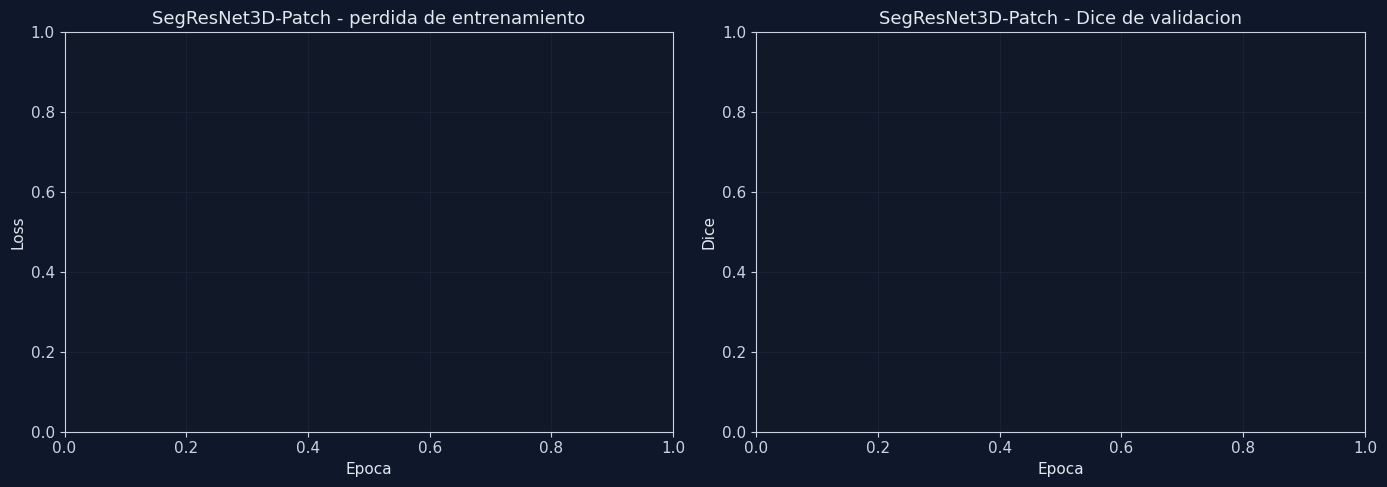

In [ ]:
# Curvas de entrenamiento.
estilo_oscuro()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#0f172a")
train_loss = historia.get("train_loss", []) or []
val_eps = historia.get("val_epochs", []) or []
val_dice = historia.get("val_dice", []) or []
if train_loss:
    axes[0].plot(train_loss, color=COLORES[MODELO_3D_NOMBRE], lw=2.5)
axes[0].set_title(f"{MODELO_3D_NOMBRE} - perdida de entrenamiento")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.25)
if val_eps and val_dice:
    axes[1].plot(val_eps, val_dice, color="#fb8c00", lw=2.5, marker="o")
axes[1].set_title(f"{MODELO_3D_NOMBRE} - Dice de validacion")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Dice")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Evaluacion: busqueda de threshold y TTA

Inferencia con `SlidingWindowInferer` (overlap=0.5, ventana gaussiana). Se
guarda el mapa de probabilidad por caso para barrer el threshold sin re-ejecutar
la red. TTA promedia 4 vistas (original + flips en cada eje espacial) cuando
esta activado.

In [ ]:
inferencias_single = inferir_todos(modelo, val_files, use_tta=False)
df_std = evaluar_inferencias(inferencias_single, threshold=0.50)
df_threshold, threshold_optimo, df_final, resumen_final = buscar_threshold(
    inferencias_single, mode="single"
)
print(f"Threshold optimo (single): {threshold_optimo:.2f}")
print("Resumen final:", resumen_final)

  inferencia single: 1/13 lung_053


/home/pyros05/Escritorio/Proyecto_MONAI/.venv/lib/python3.11/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/pyros05/Escritorio/Proyecto_MONAI/.venv/lib/python3.11/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at

  inferencia single: 2/13 lung_006
  inferencia single: 3/13 lung_084
  inferencia single: 4/13 lung_020
  inferencia single: 5/13 lung_075
  inferencia single: 6/13 lung_010


KeyboardInterrupt: 

In [ ]:
if SEGMENTATION_ENABLE_TTA_FINAL:
    inferencias_tta = inferir_todos(modelo, val_files, use_tta=True)
    df_threshold_tta, threshold_tta, df_final_tta, resumen_tta = buscar_threshold(
        inferencias_tta, mode="tta"
    )
    print(f"Threshold optimo (TTA): {threshold_tta:.2f}")
    print("Resumen TTA:", resumen_tta)
else:
    inferencias_tta = None
    df_threshold_tta = None
    threshold_tta = None
    resumen_tta = None
    df_final_tta = None
    print("TTA final desactivado.")

In [ ]:
# Curva de threshold + lineas verticales del optimo.
estilo_oscuro()
fig, ax = plt.subplots(figsize=(11, 5), facecolor="#0f172a")
ax.plot(df_threshold["threshold"], df_threshold["dice_mean"], marker="o", lw=2.2, label="single")
ax.axvline(
    threshold_optimo, color="#f97316", lw=1.5, ls="--", label=f"single={threshold_optimo:.2f}"
)
if df_threshold_tta is not None and threshold_tta is not None:
    ax.plot(
        df_threshold_tta["threshold"],
        df_threshold_tta["dice_mean"],
        marker="s",
        lw=2.2,
        label="TTA",
    )
    ax.axvline(threshold_tta, color="#22c55e", lw=1.5, ls="--", label=f"TTA={threshold_tta:.2f}")
ax.set_title(f"Busqueda de threshold para {MODELO_3D_NOMBRE}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Dice medio")
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Tabla de metricas por caso (mejor threshold con TTA si esta disponible, si no single).
df_show = df_final_tta if df_final_tta is not None else df_final
df_show.sort_values("dice", ascending=False)

## 10. Comparativa frente al historico

In [ ]:
parametros = int(historia.get("n_params", contar_parametros(modelo)))
tiempo_total_s = float(historia.get("tiempo_total_s", 0.0))
nombre_regimen = NOMBRES_REGIMEN.get(
    SEGMENTATION_AUGMENT_LEVEL, str(SEGMENTATION_AUGMENT_LEVEL)
).lower()

filas_3d = [
    fila_comparativa(
        metodo=f"{MODELO_3D_NOMBRE} (std thresh=0.50)",
        tipo="3D patch",
        df_eval=df_std,
        tiempo_total_s=tiempo_total_s,
        parametros=parametros,
    ),
    fila_comparativa(
        metodo=f"{MODELO_3D_NOMBRE} ({nombre_regimen}, thresh={threshold_optimo:.2f})",
        tipo="3D patch",
        df_eval=df_final,
        tiempo_total_s=tiempo_total_s,
        parametros=parametros,
    ),
]
if df_final_tta is not None and threshold_tta is not None:
    filas_3d.append(
        fila_comparativa(
            metodo=f"{MODELO_3D_NOMBRE} ({nombre_regimen}+TTA, thresh={threshold_tta:.2f})",
            tipo="3D patch+TTA",
            df_eval=df_final_tta,
            tiempo_total_s=tiempo_total_s,
            parametros=parametros,
        )
    )

df_comp = pd.concat(
    [pd.DataFrame(LEGACY_3D_METRICS), pd.DataFrame(filas_3d)]
    + ([pd.DataFrame(cargar_fila_baseline_2d())] if cargar_fila_baseline_2d() else [])
    + ([pd.DataFrame(cargar_fila_cascada_historica())] if cargar_fila_cascada_historica() else []),
    ignore_index=True,
)
df_comp[
    [
        "metodo",
        "tipo",
        "dice_medio",
        "hd95_medio_mm",
        "sensibilidad",
        "especificidad",
        "n_eval",
        "parametros",
    ]
]

In [ ]:
# Bar chart comparativo.
estilo_oscuro()
fig, ax = plt.subplots(figsize=(14, 6), facecolor="#0f172a")
color_por_tipo = {
    "3D legado": COLORES["3D legado"],
    "3D patch": COLORES[MODELO_3D_NOMBRE],
    "3D patch+TTA": "#22c55e",
    "2D axial historico": "#64748b",
    "Cascada historica": "#94a3b8",
}
colores = [color_por_tipo.get(str(t), "#94a3b8") for t in df_comp["tipo"]]
bars = ax.bar(range(len(df_comp)), df_comp["dice_medio"], color=colores, alpha=0.9, width=0.65)
for bar, valor in zip(bars, df_comp["dice_medio"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        float(valor) + 0.01,
        f"{float(valor):.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_xticks(range(len(df_comp)))
ax.set_xticklabels([str(m)[:34] for m in df_comp["metodo"]], rotation=20, ha="right", fontsize=9)
ax.set_title("Comparativa: legado 3D, SegResNet 3D activo y referencias historicas")
ax.set_ylabel("Dice medio")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 11. Visualizacion de predicciones

In [ ]:
inferencias_para_figura = inferencias_tta if inferencias_tta is not None else inferencias_single
threshold_para_figura = threshold_tta if threshold_tta is not None else threshold_optimo
df_para_figura = df_final_tta if df_final_tta is not None else df_final

if not df_para_figura.empty and inferencias_para_figura is not None:
    top_ids = df_para_figura.sort_values("dice", ascending=False)["case_id"].tolist()[
        : min(3, len(df_para_figura))
    ]
    inf_por_id = {inf["case_id"]: inf for inf in inferencias_para_figura}
    estilo_oscuro()
    fig, axes = plt.subplots(
        len(top_ids), 3, figsize=(15, 5 * len(top_ids)), squeeze=False, facecolor="#0f172a"
    )
    for fila, case_id in enumerate(top_ids):
        inf = inf_por_id[case_id]
        pred = aplicar_threshold(inf, threshold=threshold_para_figura, cleanup=True)
        label = inf.get("label")
        z_indices = (
            seleccionar_indices_tumor(label, n=1)
            if label is not None
            else [inf["image"].shape[0] // 2]
        )
        z = z_indices[0]
        paneles = [
            ("Slice axial", None),
            ("Ground truth", label),
            (f"Pred thresh={threshold_para_figura:.2f}", pred),
        ]
        for col, (titulo, mascara) in enumerate(paneles):
            ax_i = axes[fila, col]
            ax_i.imshow(np.clip(inf["image"][z], 0, 1), cmap="gray", origin="lower")
            if mascara is not None and np.sum(mascara[z] > 0) > 0:
                ax_i.contour(
                    mascara[z] > 0, levels=[0.5], colors=["#ef4444"], linewidths=1.8, origin="lower"
                )
            ax_i.set_title(f"{case_id} - {titulo}")
            ax_i.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Sin casos con label en validacion para visualizar.")

## 12. Ablacion: fraccion de datos vs regimen de augmentacion

Importante: con `MONAI_FAST_DEV=1` se ejecuta solo una corrida minima. Para la
ablacion completa (3 fracciones x 2 regimenes = 6 entrenamientos) deshabilita
FAST_DEV y deja correr la celda; tarda ~6x el tiempo de un entrenamiento.

In [ ]:
def ejecutar_ablacion() -> pd.DataFrame:
    """Entrena 3 fracciones (25/50/100%) x 2 regimenes (Base/Fuerte) y guarda CSV."""
    data_dicts_loc = construir_data_dicts()
    if FAST_DEV_RUN:
        data_dicts_loc = data_dicts_loc[:5]
    train_loc, val_loc = split_kfold(data_dicts_loc, fold_idx=KFOLD_DEFAULT_INDEX)
    if FAST_DEV_RUN:
        train_loc = train_loc[:3]
        val_loc = val_loc[:1]

    resultados: list[dict] = []
    fracciones_eval = [1.0] if FAST_DEV_RUN else FRACCIONES_DATOS
    for fraccion in fracciones_eval:
        subset = seleccionar_subconjunto(train_loc, fraccion)
        for regimen in [1, 2]:
            print(
                f"\nEntrenando ablacion: frac={fraccion:.0%} "
                f"regimen={NOMBRES_REGIMEN[regimen]} casos={len(subset)}"
            )
            modelo_abl, historia_abl = entrenar_modelo(
                train_files=subset,
                val_files=val_loc,
                augment_level=regimen,
                num_epocas=NUM_EPOCAS_ABLACION_3D,
                checkpoint_path=None,
                descripcion=f"fraccion={fraccion:.0%} regimen={NOMBRES_REGIMEN[regimen]}",
            )
            inferencias_abl = inferir_todos(modelo_abl, val_loc, use_tta=False)
            dices = []
            for inf in inferencias_abl:
                if "label" not in inf:
                    continue
                pred = aplicar_threshold(inf, threshold=0.5, cleanup=True)
                dices.append(dice_score(pred, inf["label"]))
            dice_medio = round(float(sum(dices) / max(len(dices), 1)), 4)
            resultados.append(
                {
                    "fraccion": fraccion,
                    "regimen": regimen,
                    "nombre_regimen": NOMBRES_REGIMEN[regimen],
                    "n_train_casos": len(subset),
                    "mejor_dice": dice_medio,
                    "mejor_epoca": int(historia_abl["mejor_epoca"]),
                    "tiempo_s": float(historia_abl["tiempo_total_s"]),
                    "fast_dev_run": FAST_DEV_RUN,
                }
            )
    df = pd.DataFrame(resultados)
    guardar_csv(df, DIR_METRICAS / "f6_ablacion.csv")
    return df


ruta_ablacion = DIR_METRICAS / "f6_ablacion.csv"
if ruta_ablacion.exists() and not FAST_DEV_RUN:
    df_abl = pd.read_csv(ruta_ablacion)
    print(f"Cargando ablacion existente: {ruta_ablacion.name}")
else:
    print("Ejecutando ablacion (puede tardar)...")
    df_abl = ejecutar_ablacion()
df_abl

In [ ]:
estilo_oscuro()
if not df_abl.empty:
    fig, ax = plt.subplots(figsize=(11, 6), facecolor="#0f172a")
    for regimen in [1, 2]:
        sub = df_abl[df_abl["regimen"] == regimen].sort_values("fraccion")
        if sub.empty:
            continue
        ax.plot(
            sub["fraccion"] * 100,
            sub["mejor_dice"],
            marker="o",
            lw=2.5,
            ms=8,
            color=COLORES[NOMBRES_REGIMEN[regimen]],
            label=NOMBRES_REGIMEN[regimen],
        )
        for _, row in sub.iterrows():
            ax.annotate(
                f"{row['mejor_dice']:.3f}",
                (row["fraccion"] * 100, row["mejor_dice"]),
                textcoords="offset points",
                xytext=(5, 8),
                fontsize=9,
            )
    ax.set_title("Impacto de la augmentacion en SegResNet 3D")
    ax.set_xlabel("Fraccion de casos de entrenamiento (%)")
    ax.set_ylabel("Dice medio en validacion")
    ax.set_xticks([25, 50, 100])
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 13. Conclusiones

- El refactor a SegResNet 3D patch-based reemplaza ~1200 lineas de pipeline
  custom (manifest 2D, priors anatomicos, augmentacion numpy ad-hoc) por
  componentes MONAI nativos. La superficie de mantenimiento se reduce a ~370
  lineas de orquestacion.
- El balance pos/neg, antes gestionado con muestreo de slices custom, se delega
  ahora a `RandCropByPosNegLabeld(pos=1, neg=1, num_samples=4)`.
- Las palancas relevantes (loss weights, augmentacion, threshold, sliding
  window) quedan expuestas como variables de entorno y configuradas con
  defaults derivados de la evidencia historica (regimen Base, threshold
  ranking robustecido por `zero_dice_cases`, MIN_COMPONENT_SIZE en 256 voxels).

**Lo que sigue siendo limitante y queda como trabajo futuro:**
- Tamano de validacion pequeno (n=13). El K-Fold permite usar las 5 vueltas
  para obtener una estimacion mas robusta del Dice.
- Cabe considerar pesos de la loss (`MONAI_LOSS_LAMBDA_DICE>0.5`) o gamma mas
  bajo (`MONAI_LOSS_FOCAL_GAMMA<2`) para iterar sobre la calibracion.
- El postproceso filtra por mascara pulmonar derivada de HU + componentes
  minimos. En tumores subpleurales conviene analizar si la mascara los
  excluye accidentalmente.

---

**Repositorio:** `Proyecto_MONAI` | **Pipeline activo:** `SegResNet3D-Patch`

Cuaderno auto-contenido: todo el pipeline esta inline. Solo requiere paquetes
del entorno virtual y la carpeta `data/Task06_Lung` (descargada
automaticamente si no existe).